# Stochastic Gradient Descent

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
import time
import re
import joblib
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import warnings
warnings.filterwarnings('ignore')
# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

True

back to root to call functions from helpers.py file

In [2]:
import os
from pathlib import Path
print(Path.cwd())
os.chdir(Path('..').resolve())
from src.utils.helpers import save
print(Path.cwd())

/mnt/d/career/digilians/sentiment-analysis-of-amazon-reviews-using-machine-learning/notebooks
/mnt/d/career/digilians/sentiment-analysis-of-amazon-reviews-using-machine-learning


## Data Acquisition

load dataset

In [3]:
X_train_tfidf = sp.load_npz('data/vectorizers/X_train_tfidf.npz').tocsr()
print(f"X_train shape: {X_train_tfidf.shape}")
y_train = pd.read_csv('data/processed/y_train.csv').squeeze()
print(f"y_train shape: {y_train.shape}")

X_train shape: (79972, 100000)
y_train shape: (79972,)


In [4]:
X_valid = sp.load_npz('data/vectorizers/X_valid_tfidf.npz').tocsr()
print(f"X_valid shape: {X_valid.shape}")
y_valid = pd.read_csv('data/processed/y_valid.csv').squeeze()
print(f"y_valid shape: {y_valid.shape}")

X_valid shape: (20000, 100000)
y_valid shape: (20000,)


In [5]:
X_test_tfidf = sp.load_npz('data/vectorizers/X_test_tfidf.npz').tocsr()
print(f"X_test shape: {X_test_tfidf.shape}")
y_test = pd.read_csv('data/processed/y_test.csv').squeeze()
print(f"y_test shape: {y_test.shape}")

X_test shape: (20000, 100000)
y_test shape: (20000,)


## Stochastic Gradient Descent Model Training

In [6]:
# Train SGD Classifier
print("Training Stochastic Gradient Descent Classifier...")
start_time = time.time()
sgd_classifier = SGDClassifier(
    loss='hinge',  # SVM loss
    penalty='l2',
    alpha=0.0001,
    max_iter=1000,
    random_state=42,
    n_jobs=-1,
    verbose=0,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=5
)
sgd_classifier.fit(X_train_tfidf, y_train)
training_time = time.time() - start_time
print(f"Training completed in {training_time:.4f} seconds")

Training Stochastic Gradient Descent Classifier...


Training completed in 0.6197 seconds


## 

## Model Evaluation

In [7]:
# Make predictions
y_pred = sgd_classifier.predict(X_test_tfidf)
# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
# Print results
print("SGD CLASSIFIER - PERFORMANCE METRICS")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"Training Time: {training_time:.4f} seconds")

SGD CLASSIFIER - PERFORMANCE METRICS
Accuracy:  0.8794
Precision: 0.8766
Recall:    0.8822
F1-Score:  0.8794
Training Time: 0.6197 seconds


## Classification Report

In [8]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

Classification Report:
              precision    recall  f1-score   support

    Negative       0.88      0.88      0.88      9966
    Positive       0.88      0.88      0.88     10034

    accuracy                           0.88     20000
   macro avg       0.88      0.88      0.88     20000
weighted avg       0.88      0.88      0.88     20000



## Confusion Matrix Visualization

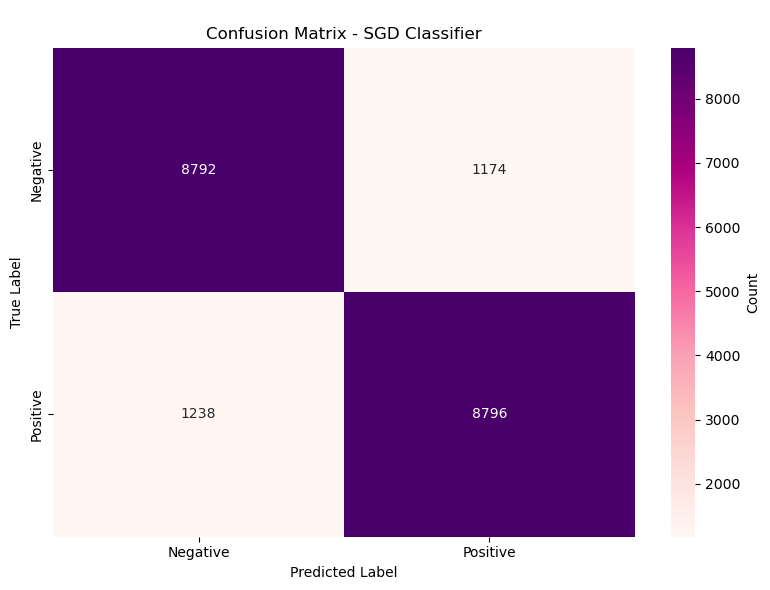

Confusion Matrix:
[[8792 1174]
 [1238 8796]]

True Negatives: 8792
False Positives: 1174
False Negatives: 1238
True Positives: 8796


In [9]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            cbar_kws={'label': 'Count'})
plt.title('\nConfusion Matrix - SGD Classifier')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('sgd_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Confusion Matrix:\n{cm}")
print(f"\nTrue Negatives: {cm[0,0]}")
print(f"False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}")
print(f"True Positives: {cm[1,1]}")

## Feature Coefficients (Feature Importance for Linear Models)

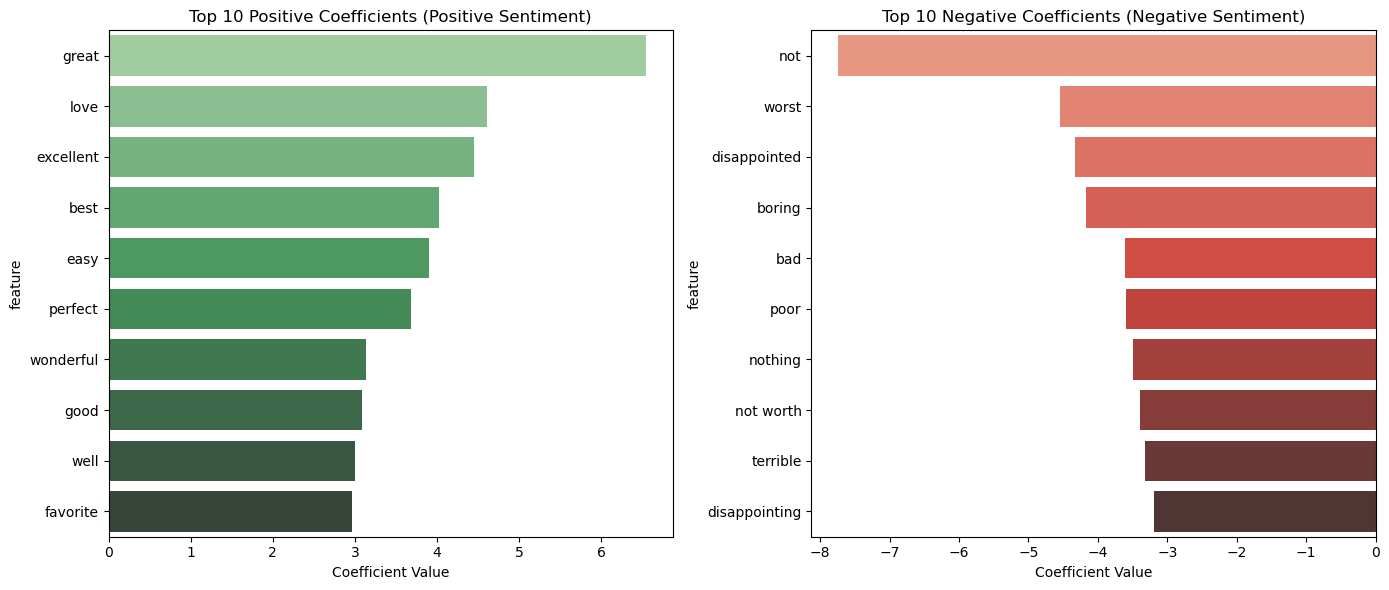


Top 10 Positive Coefficients:
  feature  coefficient
    great     6.541692
     love     4.606602
excellent     4.451825
     best     4.023629
     easy     3.897312
  perfect     3.678870
wonderful     3.131539
     good     3.082598
     well     2.996514
 favorite     2.961922

Top 10 Negative Coefficients:
      feature  coefficient
          not    -7.738862
        worst    -4.540238
 disappointed    -4.327995
       boring    -4.163852
          bad    -3.605209
         poor    -3.591817
      nothing    -3.495149
    not worth    -3.391792
     terrible    -3.326398
disappointing    -3.184444


In [10]:
# Get feature coefficients
tfidf_vectorizer = joblib.load('data/vectorizers/tfidf_vectorizer.joblib')
feature_names = tfidf_vectorizer.get_feature_names_out()
coefficients = sgd_classifier.coef_[0]
# Create DataFrame for better visualization
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients
})
# Get top positive and negative features
top_positive = coef_df.nlargest(10, 'coefficient')
top_negative = coef_df.nsmallest(10, 'coefficient')
# Plot top coefficients
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(data=top_positive, x='coefficient', y='feature', palette='Greens_d', ax=axes[0])
axes[0].set_title('Top 10 Positive Coefficients (Positive Sentiment)')
axes[0].set_xlabel('Coefficient Value')
sns.barplot(data=top_negative, x='coefficient', y='feature', palette='Reds_d', ax=axes[1])
axes[1].set_title('Top 10 Negative Coefficients (Negative Sentiment)')
axes[1].set_xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig('sgd_feature_coefficients.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nTop 10 Positive Coefficients:")
print(top_positive.to_string(index=False))
print("\nTop 10 Negative Coefficients:")
print(top_negative.to_string(index=False))

## Model Convergence Analysis

In [11]:
# Check number of iterations
print(f"\nModel Convergence Information:")
print(f"Number of iterations: {sgd_classifier.n_iter_}")
print(f"Number of features: {sgd_classifier.n_features_in_}")
print(f"Classes: {sgd_classifier.classes_}")
print(f"Loss value: {sgd_classifier.loss}")


Model Convergence Information:
Number of iterations: 7
Number of features: 100000
Classes: [1 2]
Loss value: hinge


## Model Summary

In [12]:
print("STOCHASTIC GRADIENT DESCENT MODEL SUMMARY")
print(f"\nModel Parameters:")
print(f"  - Loss Function: {sgd_classifier.loss}")
print(f"  - Penalty: {sgd_classifier.penalty}")
print(f"  - Alpha (Learning Rate): {sgd_classifier.alpha}")
print(f"  - Max Iterations: {sgd_classifier.max_iter}")
print(f"  - Early Stopping: {sgd_classifier.early_stopping}")
print(f"\nFeature Engineering:")
print(f"  - Vectorizer: TF-IDF")
print(f"  - Max Features: 5000")
print(f"  - N-gram Range: (1, 2)")
print(f"  - Min Document Frequency: 5")
print(f"  - Max Document Frequency: 0.8")
print(f"\nPerformance:")
print(f"  - Accuracy:  {accuracy:.4f}")
print(f"  - Precision: {precision:.4f}")
print(f"  - Recall:    {recall:.4f}")
print(f"  - F1-Score:  {f1:.4f}")
print(f"  - Training Time: {training_time:.4f} seconds")
print(f"\nTraining Details:")
print(f"  - Iterations Required: {sgd_classifier.n_iter_}")
print(f"  - Number of Features Used: {sgd_classifier.n_features_in_}")

STOCHASTIC GRADIENT DESCENT MODEL SUMMARY

Model Parameters:
  - Loss Function: hinge
  - Penalty: l2
  - Alpha (Learning Rate): 0.0001
  - Max Iterations: 1000
  - Early Stopping: True

Feature Engineering:
  - Vectorizer: TF-IDF
  - Max Features: 5000
  - N-gram Range: (1, 2)
  - Min Document Frequency: 5
  - Max Document Frequency: 0.8

Performance:
  - Accuracy:  0.8794
  - Precision: 0.8766
  - Recall:    0.8822
  - F1-Score:  0.8794
  - Training Time: 0.6197 seconds

Training Details:
  - Iterations Required: 7
  - Number of Features Used: 100000


## Saving the Model and Pipeline

In [13]:
save(model_base='data/models', model=sgd_classifier, model_name='11_stochastic_gradient_descent_classifier.joblib')

Saved model 11_stochastic_gradient_descent_classifier.joblib to data/models/11_stochastic_gradient_descent_classifier.joblib


{'model': PosixPath('data/models/11_stochastic_gradient_descent_classifier.joblib')}